Fetching data from Earth Engine (this may take a few seconds)...


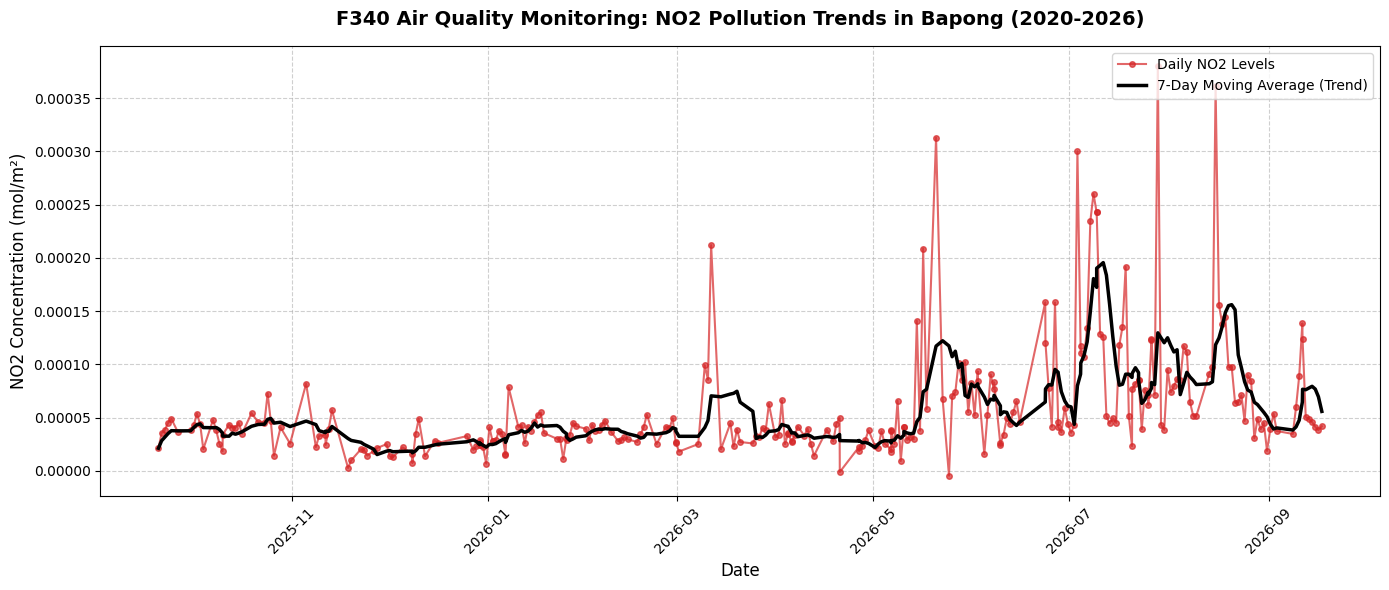


📊 F340 POLLUTION ANALYSIS SUMMARY FOR BAPONG:
   • Average NO2 Level: 5.77e-05 mol/m²
   • Peak NO2 Level:    3.80e-04 mol/m²
   • Total Data Points: 286 days of satellite monitoring


Map(center=[-25.708509262814562, 27.681093381613852], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
import ee
import geemap
import ipyleaflet
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Authenticate and Initialize
ee.Authenticate()
ee.Initialize(project='earth22')

# Create map centered on Bapong
# geemap uses [latitude, longitude]
m = geemap.Map(center=[-25.708509262814562, 27.681093381613852], zoom=13)
# Add the fullscreen control to the map
m.add_control(ipyleaflet.FullScreenControl())
# Add Esri Satellite basemap
m.add_basemap('Esri.WorldImagery')

# Create AOI around Bapong
# ee.Geometry uses [longitude, latitude]
point = ee.Geometry.Point([27.681093381613852, -25.708509262814562])
aoi = point.buffer(5000)  # 5km radius around Bapong

# 1. Load and Filter Sentinel-1 GRD Data
s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD')
s1_filtered = s1_collection.filterBounds(aoi) \
                           .filterDate('2025-09-20', '2026-09-19') \
                           .filter(ee.Filter.eq('instrumentMode', 'IW'))
# We select the 'VV' polarization band, which is best for ground surface changes
early_s1 = s1_filtered.filterDate('2025-09-01', '2026-02-28').select('VV').median()
late_s1 = s1_filtered.filterDate('2026-03-01', '2026-09-19').select('VV').median()

# 3. Convert to Decibels (dB) for accurate radar analysis
# Radar data is logarithmic. Converting to dB makes the changes easier to see.
early_db = early_s1.multiply(10).log10()
late_db = late_s1.multiply(10).log10()

# 4. Calculate Ground Change (Instability)
# Subtracting early from late shows how the ground surface changed over 6 months
ground_change = late_db.subtract(early_db).rename('Ground_Change_dB')

# 5. Visualize the Instability
# Red = High positive change (Ground dug up, new pits, rougher surface)
# Blue = High negative change (Ground subsidence, sinking, smoother surface)
# White = Stable ground
change_vis = {
    'min': -3,
    'max': 3,
    'palette': ['blue', 'white', 'red']
}
m.addLayer(ground_change, change_vis, 'Ground Instability (S1 Radar)')


s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
filtered_s2 = s2_collection.filterDate('2025-09-20', '2026-09-19') \
                           .filterBounds(aoi) \
                           .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 20)

# Create the composite
composite = filtered_s2.median()

# NDVI: Vegetation Health
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

# MNDWI: Water / Sinkholes
mndwi = composite.normalizedDifference(['B3', 'B11']).rename('MNDWI')

severe_bare_earth = ndvi.lt(0.0)

# 2. Exclude the main river/large water bodies so the red doesn't cover the river
# (MNDWI greater than 0.1 is usually open water)
not_large_water = mndwi.lt(0.1)

# 3. Combine them: Severe bare earth AND not the main river
mining_scars = severe_bare_earth.And(not_large_water)

# 4. Visualize (Bright Red, but only for the severe areas)
scar_vis = {
    'palette': ['FF0000'],
    'opacity': 0.9
}
# Layer 1: True Color (Base reference)
m.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'True Color Satellite')

# Layer 2: NDVI
m.addLayer(ndvi, {'min': -0.2, 'max': 0.8, 'palette': ['brown', 'yellow', 'green']}, 'NDVI (Vegetation Health)')

# Layer 3: MNDWI
m.addLayer(mndwi, {'min': -0.5, 'max': 0.5, 'palette': ['white', 'lightblue', 'darkblue']}, 'MNDWI (Water/Sinkholes)')

# Add the clean layer to the map
m.addLayer(mining_scars, scar_vis, 'F340 Severe Mining Scars')

# ==========================================
# FEATURE: AIR POLLUTION TIME SERIES CHART
# ==========================================

# 1. Load and filter Sentinel-5P NO2 data
s5p = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2') \
    .filterDate('2025-09-20', '2026-09-19') \
    .filterBounds(aoi) \
    .select('tropospheric_NO2_column_number_density')

# 2. Function to extract the mean NO2 value for the AOI for each image
def extract_no2(image):
    # Calculate mean NO2 within the Bapong AOI
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=1000,  # 1km scale is appropriate for Sentinel-5P
        maxPixels=1e9
    )
    # Return a Feature containing the timestamp and the NO2 value
    return ee.Feature(None, {
        'time': image.get('system:time_start'),
        'no2': stats.get('tropospheric_NO2_column_number_density')
    })

# 3. Map the function and filter out days with no data (null values)
features = s5p.map(extract_no2).filter(ee.Filter.neq('no2', None))

# 4. Extract the data to Python
print("Fetching data from Earth Engine (this may take a few seconds)...")
feature_collection = features.getInfo()

# 5. Convert to a Pandas DataFrame for plotting
data = []
for f in feature_collection['features']:
    props = f['properties']
    no2_val = props.get('no2')
    if no2_val is not None:
        data.append({
            'date': pd.to_datetime(props['time'], unit='ms'),
            'no2': no2_val
        })

df = pd.DataFrame(data).sort_values('date')

# 6. Create the Chart
if not df.empty:
    plt.figure(figsize=(14, 6))

    # Plot the data points and connect them with a line
    plt.plot(df['date'], df['no2'], color='#d62728', linewidth=1.5, marker='o', markersize=4, alpha=0.7, label='Daily NO2 Levels')

    # Add a rolling average (7-day) to smooth out the noise and show the true trend
    df['no2_rolling'] = df['no2'].rolling(window=7, min_periods=1).mean()
    plt.plot(df['date'], df['no2_rolling'], color='black', linewidth=2.5, label='7-Day Moving Average (Trend)')

    # Styling for a professional pitch
    plt.title('F340 Air Quality Monitoring: NO2 Pollution Trends in Bapong (2020-2026)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NO2 Concentration (mol/m²)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show the chart
    plt.show()

    # Print summary statistics for your pitch
    print("\n" + "="*50)
    print("📊 F340 POLLUTION ANALYSIS SUMMARY FOR BAPONG:")
    print(f"   • Average NO2 Level: {df['no2'].mean():.2e} mol/m²")
    print(f"   • Peak NO2 Level:    {df['no2'].max():.2e} mol/m²")
    print(f"   • Total Data Points: {len(df)} days of satellite monitoring")
    print("="*50)
else:
    print("No data was returned. This can happen if there is heavy cloud cover in the selected date range. try adjusting the range")
m